In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


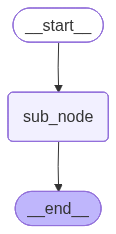

In [3]:
from typing_extensions import TypedDict
from typing import List

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

llm = ChatPerplexity(model="sonar-pro")

class SubState(MessagesState):
    mode: str

def subgraph_node(state: SubState) -> SubState:
    messages = state.get("messages", [])
    response = llm.invoke(messages)
    return {
        "messages": messages + [response],
        "mode": state.get("mode", "summary"),
    }

sub_builder = StateGraph(SubState)
sub_builder.add_node("sub_node", subgraph_node)
sub_builder.set_entry_point("sub_node")
sub_builder.add_edge("sub_node", END)

sub_memory = MemorySaver()
subgraph = sub_builder.compile(checkpointer=sub_memory)

display(Image(subgraph.get_graph().draw_mermaid_png()))

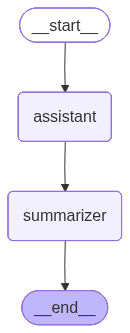

In [4]:
class MainState(TypedDict):
    topic: str
    messages: List[BaseMessage]
    summary: str

def main_node(state: MainState) -> MainState:
    messages = state["messages"]
    response = llm.invoke(messages)
    return {
        "topic": state["topic"],
        "messages": messages + [response],
        "summary": state.get("summary", ""),
    }

def call_subgraph(state: MainState) -> MainState:
    topic = state["topic"]
    sub_input = {
        "messages": [HumanMessage(content=f"Summarize {topic} in two friendly sentences.")],
        "mode": "summary",
    }
    sub_output = subgraph.invoke(sub_input)
    summary = sub_output["messages"][-1].content
    return {
        "topic": topic,
        "messages": state["messages"],
        "summary": summary,
    }

main_builder = StateGraph(MainState)
main_builder.add_node("assistant", main_node)
main_builder.add_node("summarizer", call_subgraph)

main_builder.set_entry_point("assistant")
main_builder.add_edge("assistant", "summarizer")
main_builder.add_edge("summarizer", END)

main_memory = MemorySaver()
main_graph = main_builder.compile(checkpointer=main_memory)

display(Image(main_graph.get_graph().draw_mermaid_png()))

In [6]:
from langchain_core.messages import HumanMessage

config1 = {"configurable": {"thread_id": "subgraph-run-1"}}

initial1 = {
    "topic": "beginner budgeting tips",
    "messages": [HumanMessage(content="Give me two simple budgeting tips.")],
    "summary": "",
}

print("Running first subgraph example...\n")
result1 = None
for event in main_graph.stream(initial1, config=config1, stream_mode="values"):
    result1 = event

print("Final response:")
result1["messages"][-1].pretty_print()
print("\nGenerated summary:")
print(result1["summary"])

Running first subgraph example...

Final response:
================================== Ai Message ==================================

Here are two simple budgeting tips to get you started:

**Track Your Spending**
The first step to effective budgeting is understanding where your money actually goes.[1] Review your bank and credit card statements from the past one to two months, then categorize your expenses (housing, food, transportation, subscriptions, etc.). This reveals spending patterns and often uncovers surprising expenses like takeout or forgotten subscriptions that you can cut back on.[1]

**Use the 50/30/20 Rule**
A straightforward way to structure your budget is the 50/30/20 rule: allocate 50% of your income to needs (rent, bills, groceries), 30% to wants (dining out, entertainment, travel), and 20% to savings or debt repayment.[1][6] You can adjust these percentages to match your lifestyle, but this provides a helpful starting point for organizing your finances.[1]

Generated

In [5]:
config2 = {"configurable": {"thread_id": "subgraph-run-2"}}

initial2 = {
    "topic": "healthy study habits",
    "messages": [HumanMessage(content="Share two habits that improve study focus.")],
    "summary": "",
}

print("Running second subgraph example...\n")
result2 = None
for event in main_graph.stream(initial2, config=config2, stream_mode="values"):
    result2 = event

print("Final response:")
result2["messages"][-1].pretty_print()
print("\nGenerated summary:")
print(result2["summary"])

Running second subgraph example...

Final response:
================================== Ai Message ==================================

Two habits that significantly improve study focus are **eliminating distractions** and **using structured study intervals with breaks**.

Eliminating distractions involves choosing a quiet, dedicated study space and minimizing interruptions from technology or your environment. This can include turning off unnecessary Wi-Fi, silencing your phone, and keeping distracting items out of reach, which helps maintain concentration and prevents unnecessary task-switching[1][3].

Using structured study intervals, such as the **Pomodoro Technique**, means studying in short, focused sessions (e.g., 25 minutes), followed by a brief break (e.g., 5 minutes). This approach helps to maintain attention, reduces mental fatigue, and supports better retention and productivity. Research indicates that regular breaks boost focus and learning efficiency[2][3][4][5].

Adopting t

In [1]:
print("Direct subgraph invocation...\n")

direct_input = {
    "messages": [HumanMessage(content="Summarize the benefits of hydration in two sentences.")],
    "mode": "summary",
}

direct_output = subgraph.invoke(direct_input)

for msg in direct_output["messages"]:
    msg.pretty_print()

Direct subgraph invocation...



NameError: name 'HumanMessage' is not defined